In [1]:
#Importing libraries
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import ast 
import seaborn as sns

#Loading data
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset['train'].to_pandas()

#Data cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

d:\Anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


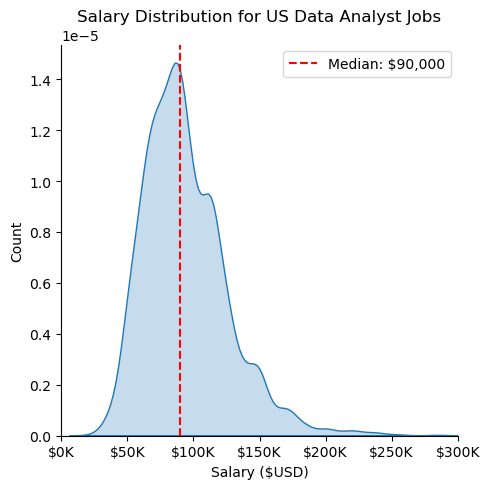

In [5]:
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()
df_DA_US = df_DA_US.dropna(subset=['salary_year_avg'])

# 1. Create the Histogram
# df_DA_US['salary_year_avg'].plot(kind='hist', bins=30, edgecolor='black')
sns.displot(data=df_DA_US['salary_year_avg'], kind='kde', fill=True)


# 2. Calculate and plot the Median Line
median_salary = df_DA_US['salary_year_avg'].median()
plt.axvline(median_salary, color='red', linestyle='--', label=f'Median: ${int(median_salary):,}')

# 3. Formatting
plt.xlim(0, 300000)
plt.xlabel('Salary ($USD)')
plt.ylabel('Count')
plt.title('Salary Distribution for US Data Analyst Jobs')

# Use our thousand separator formatter for the X-axis
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000):,}K'))

plt.legend() # Shows the median label
plt.tight_layout()
plt.show()